## Dataset overview
- **Source:** Inside Airbnb, London, snapshot 19 June 2026 (insideairbnb.com/get-the-data), public data under CC BY 4.0.
- **Size:** 92,638 listings × 90 columns.
- **Features:** host details, location (neighbourhood, latitude, longitude), property (room type, bedrooms, bathrooms, amenities), price and booking rules, availability, and reviews (overall rating plus six sub-scores).
- **Project question:** which listing and host features predict a top rating (4.8 or higher), so hosts know what to improve first.
- **Why this dataset:** it is large, current, and combines numeric, categorical, text, and geographic data, which supports both EDA and a classification model. The overall rating is guest-given, so the target is observed, not estimated.
- **Complexity:** 14 columns are completely empty in this snapshot, price is stored as text and missing for about a third of listings, missing values also appear as text placeholders, and a quarter of listings have no rating yet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/listings.csv.gz")
print(df.shape)

(92638, 90)


## Step 2: Column audit
Each column is checked for data type, missing rate, and number of unique values. Text placeholders such as "N/A" or "-" are checked separately, because they count as present values even though they hold no information.

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_pct": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
print(audit.sort_values("missing_pct", ascending=False).head(20))
print(df["price"].dtype, df["price"].head(3).tolist())

stand_ins = ["N/A", "NA", "null", "?", "-", "unknown", ""]
for c in df.select_dtypes(exclude="number").columns:
    n = df[c].isin(stand_ins).sum()
    if n:
        print(c, n)

                                dtype  missing_pct  n_unique
host_total_listings_count     float64        100.0         0
license                       float64        100.0         0
host_response_rate            float64        100.0         0
neighbourhood                 float64        100.0         0
host_acceptance_rate          float64        100.0         0
host_verifications            float64        100.0         0
host_since                    float64        100.0         0
host_response_time            float64        100.0         0
host_thumbnail_url            float64        100.0         0
instant_bookable              float64        100.0         0
neighborhood_overview         float64        100.0         0
neighbourhood_group_cleansed  float64        100.0         0
host_neighbourhood            float64        100.0         0
calendar_updated              float64        100.0         0
host_about                        str         46.9     23518
bathrooms               

## Step 3: Cleaning
Steps, in order: drop empty and metadata columns, convert text placeholders to missing, convert price from text to numbers, cap extreme prices in a new column, recover bathroom counts from the bathroom text, check for duplicates, and define the target `top_rated`. All listings stay in the cleaned file for EDA; the model will use rated listings only.

In [3]:
import os
import numpy as np

clean = df.copy()
notes = {}

# A. Drop columns that are 100% empty
empty_cols = audit.index[audit["missing_pct"] == 100].tolist()
clean = clean.drop(columns=empty_cols)
notes["empty_cols"] = len(empty_cols)

# B. Drop URL and scrape metadata (keep id as the join key)
meta_cols = [c for c in clean.columns if c.endswith("_url") or c in ["scrape_id", "last_scraped", "source", "calendar_last_scraped"]]
clean = clean.drop(columns=meta_cols)
notes["meta_cols"] = len(meta_cols)

# C. Text stand-ins become missing
stand_ins = ["N/A", "NA", "null", "?", "-", "unknown", ""]
for c in ["description", "host_about"]:
    if c in clean.columns:
        clean[c] = clean[c].where(~clean[c].isin(stand_ins))

# D. Price: text to number, impossible values to missing, cap extremes in a new column
clean["price"] = pd.to_numeric(clean["price"].str.replace(r"[$,]", "", regex=True), errors="coerce")
notes["price_zero"] = int((clean["price"] <= 0).sum())
clean.loc[clean["price"] <= 0, "price"] = np.nan
cap = clean["price"].quantile(0.99)
clean["price_capped"] = clean["price"].clip(upper=cap)
notes["price_cap"] = cap
notes["price_above_cap"] = int((clean["price"] > cap).sum())

# E. Bathrooms: recover missing values from bathrooms_text ("1.5 baths", "Half-bath")
notes["bath_filled"] = 0
if "bathrooms_text" in clean.columns:
    bt = clean["bathrooms_text"]
    num = pd.to_numeric(bt.str.extract(r"(\d+\.?\d*)")[0], errors="coerce")
    num = num.mask(num.isna() & bt.str.contains("half", case=False, na=False), 0.5)
    fill = clean["bathrooms"].isna() & num.notna()
    clean.loc[fill, "bathrooms"] = num[fill]
    notes["bath_filled"] = int(fill.sum())

# F. Duplicates, checked without id
dup = clean.drop(columns=["id"]).duplicated()
notes["duplicates"] = int(dup.sum())
clean = clean[~dup]

# G. Target: rating 0 treated as missing; top_rated = rating >= 4.8
notes["rating_zero"] = int((clean["review_scores_rating"] == 0).sum())
clean.loc[clean["review_scores_rating"] == 0, "review_scores_rating"] = np.nan
rated = clean["review_scores_rating"].notna()
clean["top_rated"] = (clean["review_scores_rating"] >= 4.8).astype("Int64").where(rated)
notes["rated"] = int(rated.sum())
notes["unrated"] = int((~rated).sum())
notes["top_share"] = clean.loc[rated, "top_rated"].mean()

# H. Where is price missing?
pm = clean["price"].isna()
notes["price_missing_pct"] = pm.mean() * 100
notes["price_same_as_quote"] = (pm == clean["price_quote_price_per_night"].isna()).mean() * 100
notes["avail0_missing"] = (clean.loc[pm, "availability_365"] == 0).mean() * 100
notes["avail0_present"] = (clean.loc[~pm, "availability_365"] == 0).mean() * 100

# I. Save
os.makedirs("../figures", exist_ok=True)
clean.to_csv("../data/listings_clean.csv", index=False)
print(clean.shape)
for k, v in notes.items():
    print(k, round(v, 2) if isinstance(v, float) else v)

(92635, 69)
empty_cols 14
meta_cols 9
price_zero 0
price_cap 1373.46
price_above_cap 623
bath_filled 34750
duplicates 3
rating_zero 3
rated 70708
unrated 21927
top_share 0.56
price_missing_pct 32.81
price_same_as_quote 100.0
avail0_missing 87.24
avail0_present 0.0


## Figure 1: Missing values by column
Shows which columns are usable and which needed a decision. Color marks the action taken.

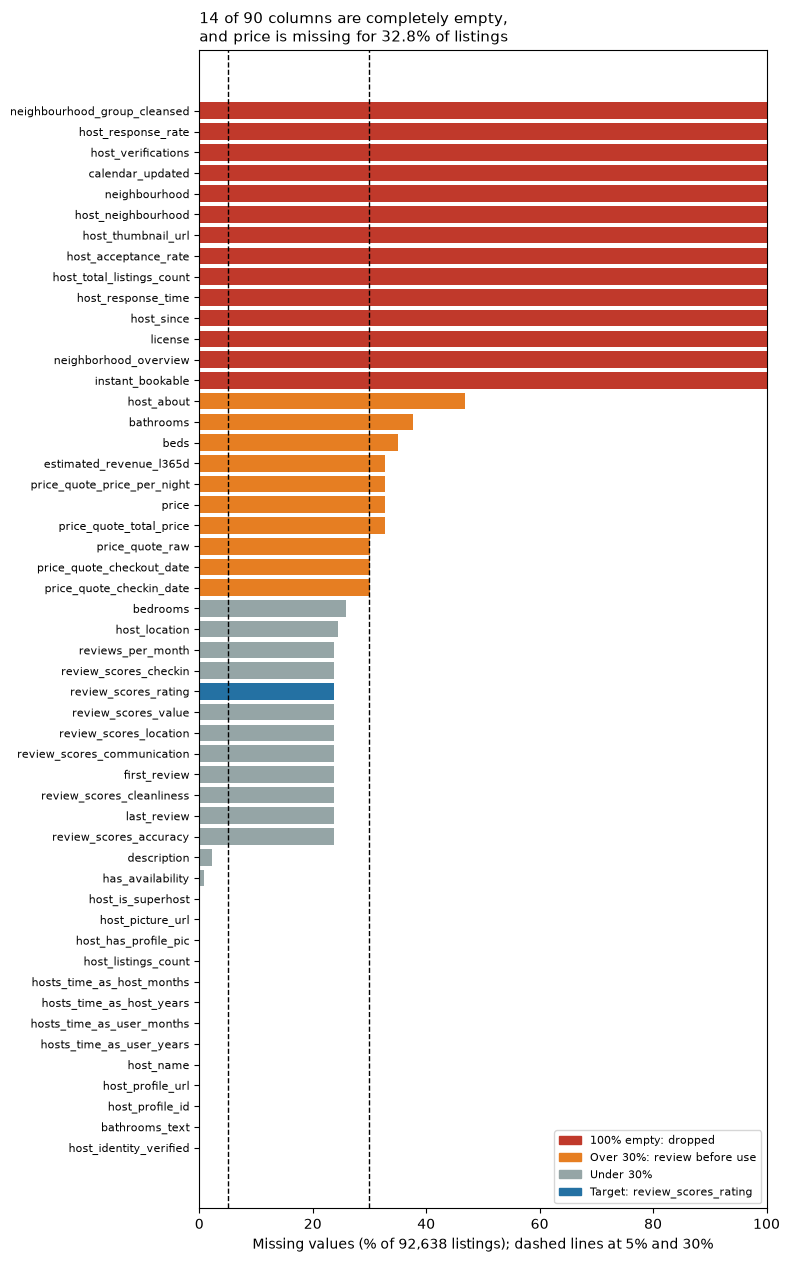

**Insight:** 14 empty columns were dropped, including host-behaviour columns (response rate, acceptance rate, response time), so those cannot be used as features. The target is missing for 23.7% of listings; these listings have no reviews, so they are excluded from the model, not imputed.

In [4]:
from matplotlib.patches import Patch
from IPython.display import Markdown, display

miss = audit.loc[audit["missing_pct"] > 0, "missing_pct"].sort_values()
colors = []
for col, v in miss.items():
    if col == "review_scores_rating":
        colors.append("#2471A3")
    elif v == 100:
        colors.append("#C0392B")
    elif v > 30:
        colors.append("#E67E22")
    else:
        colors.append("#95A5A6")

fig, ax = plt.subplots(figsize=(8, 0.22 * len(miss) + 1.5))
ax.barh(miss.index, miss.values, color=colors)
for x in (5, 30):
    ax.axvline(x, ls="--", lw=1, color="black")
ax.set_xlim(0, 100)
ax.set_xlabel("Missing values (% of 92,638 listings); dashed lines at 5% and 30%")
ax.tick_params(axis="y", labelsize=8)
ax.set_title(f"{(miss == 100).sum()} of {df.shape[1]} columns are completely empty,\n"
             f"and price is missing for {audit.loc['price', 'missing_pct']}% of listings",
             loc="left", fontsize=11)
ax.legend(handles=[Patch(color="#C0392B", label="100% empty: dropped"),
                   Patch(color="#E67E22", label="Over 30%: review before use"),
                   Patch(color="#95A5A6", label="Under 30%"),
                   Patch(color="#2471A3", label="Target: review_scores_rating")],
          loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("../figures/fig1_missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** {notes['empty_cols']} empty columns were dropped, including host-behaviour columns "
    f"(response rate, acceptance rate, response time), so those cannot be used as features. "
    f"The target is missing for {audit.loc['review_scores_rating', 'missing_pct']}% of listings; "
    f"these listings have no reviews, so they are excluded from the model, not imputed."))

## Figure 2: Price before and after cleaning
Shows the effect of capping extreme prices at the 99th percentile.

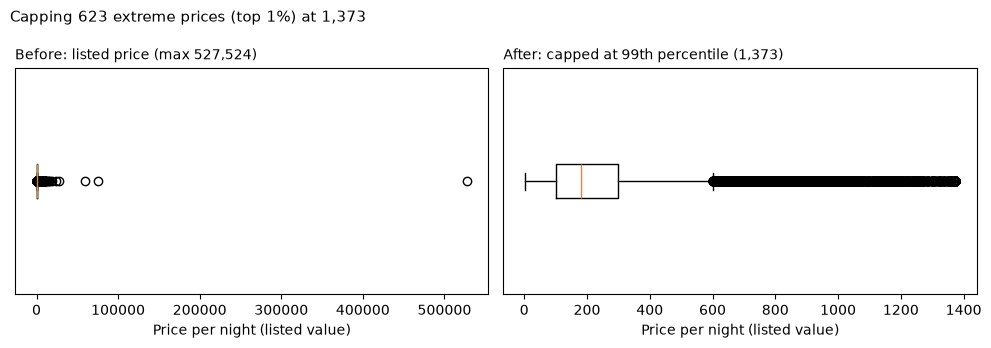

**Insight:** the top 1% of prices (623 listings) stretch the axis to 527,524. Capping keeps these listings, which still have valid ratings, while limiting their effect on charts and models. The original `price` column is kept unchanged.

In [8]:
p = clean["price"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].boxplot(p.values, orientation="horizontal")
axes[0].set_title(f"Before: listed price (max {p.max():,.0f})", loc="left", fontsize=10)
axes[1].boxplot(p.clip(upper=cap).values, orientation="horizontal")
axes[1].set_title(f"After: capped at 99th percentile ({cap:,.0f})", loc="left", fontsize=10)
for ax in axes:
    ax.set_xlabel("Price per night (listed value)")
    ax.set_yticks([])
fig.suptitle(f"Capping {notes['price_above_cap']:,} extreme prices (top 1%) at {cap:,.0f}",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.savefig("../figures/fig2_price_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

display(Markdown(
    f"**Insight:** the top 1% of prices ({notes['price_above_cap']:,} listings) stretch the axis to {p.max():,.0f}. "
    f"Capping keeps these listings, which still have valid ratings, while limiting their effect on charts and models. "
    f"The original `price` column is kept unchanged."))

## Step 4: Decision table

In [6]:
n = notes
display(Markdown(f"""
| Column / issue | Decision | Because |
|---|---|---|
| {n['empty_cols']} columns 100% empty (e.g. `host_since`, `license`) | Dropped | No values in this snapshot |
| {n['meta_cols']} URL and scrape metadata columns | Dropped; `id` kept | No analytical value; `id` joins to the calendar file |
| `price` stored as text ("$234.50") | Converted to number | Text columns are skipped by summaries and charts |
| `price` of 0 or less ({n['price_zero']} rows) | Treated as missing | A nightly price cannot be zero or negative |
| `price` missing ({n['price_missing_pct']:.1f}%) | Kept, not imputed | Same rows as missing `price_quote_price_per_night` ({n['price_same_as_quote']:.0f}% match); {n['avail0_missing']:.0f}% of these have 0 days available vs {n['avail0_present']:.0f}% of priced listings |
| {n['price_above_cap']:,} prices above the 99th percentile ({n['price_cap']:,.0f}) | Capped in new column `price_capped`; original kept | Listings have valid ratings, so capping limits influence without deleting them |
| `bathrooms` {audit.loc['bathrooms', 'missing_pct']}% missing | {n['bath_filled']:,} values recovered from `bathrooms_text` | Same information stored as text ("1.5 baths") |
| `beds` {audit.loc['beds', 'missing_pct']}% missing | Kept; decision deferred to modeling | No reliable column to recover it from |
| Text placeholders in `description`, `host_about` | Treated as missing | They look filled in but hold no information |
| Duplicate rows, checked without `id` | {n['duplicates']} found{"; dropped" if n['duplicates'] else ""} | A unique ID hides duplicates, so it is excluded from the check |
| `review_scores_rating` = 0 ({n['rating_zero']} rows) | Treated as missing | Not a valid star rating |
| {n['unrated']:,} listings with no rating | Kept for EDA; excluded from the model | A missing target cannot be filled without inventing answers |
| Review sub-scores, `host_is_superhost` | Kept for EDA; excluded from model features | Sub-scores come from the same stay as the target; Superhost status is partly decided by rating |
| New target `top_rated` | 1 if rating is 4.8 or higher, else 0 | {n['top_share']:.0%} of {n['rated']:,} rated listings are top rated |
"""))


| Column / issue | Decision | Because |
|---|---|---|
| 14 columns 100% empty (e.g. `host_since`, `license`) | Dropped | No values in this snapshot |
| 9 URL and scrape metadata columns | Dropped; `id` kept | No analytical value; `id` joins to the calendar file |
| `price` stored as text ("$234.50") | Converted to number | Text columns are skipped by summaries and charts |
| `price` of 0 or less (0 rows) | Treated as missing | A nightly price cannot be zero or negative |
| `price` missing (32.8%) | Kept, not imputed | Same rows as missing `price_quote_price_per_night` (100% match); 87% of these have 0 days available vs 0% of priced listings |
| 623 prices above the 99th percentile (1,373) | Capped in new column `price_capped`; original kept | Listings have valid ratings, so capping limits influence without deleting them |
| `bathrooms` 37.6% missing | 34,750 values recovered from `bathrooms_text` | Same information stored as text ("1.5 baths") |
| `beds` 35.1% missing | Kept; decision deferred to modeling | No reliable column to recover it from |
| Text placeholders in `description`, `host_about` | Treated as missing | They look filled in but hold no information |
| Duplicate rows, checked without `id` | 3 found; dropped | A unique ID hides duplicates, so it is excluded from the check |
| `review_scores_rating` = 0 (3 rows) | Treated as missing | Not a valid star rating |
| 21,927 listings with no rating | Kept for EDA; excluded from the model | A missing target cannot be filled without inventing answers |
| Review sub-scores, `host_is_superhost` | Kept for EDA; excluded from model features | Sub-scores come from the same stay as the target; Superhost status is partly decided by rating |
| New target `top_rated` | 1 if rating is 4.8 or higher, else 0 | 56% of 70,708 rated listings are top rated |


## Step 5: Challenges so far

In [7]:
display(Markdown(f"""
- **Host-behaviour columns are empty.** Response rate, acceptance rate, and response time have no values in this snapshot, so fewer host features are available for the model.
- **Price is incomplete.** {n['price_missing_pct']:.1f}% of listings have no price, matching the missing price quote in {n['price_same_as_quote']:.0f}% of rows, so price cannot be used for every listing.
- **The target is missing for unreviewed listings.** {n['unrated']:,} listings have no rating, so the model only describes listings that already have reviews.
- **Ratings are bunched near the top.** The median rating is 4.83 and {n['top_share']:.0%} of rated listings reach 4.8, so small rating differences decide the class.
- **Leakage risk.** Review sub-scores and Superhost status are tied to the rating, so they are excluded from model features.
"""))


- **Host-behaviour columns are empty.** Response rate, acceptance rate, and response time have no values in this snapshot, so fewer host features are available for the model.
- **Price is incomplete.** 32.8% of listings have no price, matching the missing price quote in 100% of rows, so price cannot be used for every listing.
- **The target is missing for unreviewed listings.** 21,927 listings have no rating, so the model only describes listings that already have reviews.
- **Ratings are bunched near the top.** The median rating is 4.83 and 56% of rated listings reach 4.8, so small rating differences decide the class.
- **Leakage risk.** Review sub-scores and Superhost status are tied to the rating, so they are excluded from model features.
